# Mutual Fund Analytics — Exploratory Data Analysis (EDA)

**Ticket:** Exploratory Data Analysis (EDA)
**Deliverables:** 15+ charts covering NAV trends, AUM growth, SIP inflows, category inflows, investor demographics, geographic distribution, folio growth, return correlation, and sector allocation.

This notebook reads from the cleaned datasets in `data/processed/` (produced in Day 2) and exports every chart as a PNG into `reports/eda_charts/` for use in the final report.


## Setup — imports and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

PROCESSED_DIR = "data/processed"
CHARTS_DIR = "reports/eda_charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.options.mode.chained_assignment = None

fund_master = pd.read_csv(f"{PROCESSED_DIR}/01_fund_master.csv")
nav_history = pd.read_csv(f"{PROCESSED_DIR}/02_nav_history.csv", parse_dates=["date"])
aum_by_fund_house = pd.read_csv(f"{PROCESSED_DIR}/03_aum_by_fund_house.csv", parse_dates=["date"])
monthly_sip_inflows = pd.read_csv(f"{PROCESSED_DIR}/04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv(f"{PROCESSED_DIR}/05_category_inflows.csv")
industry_folio_count = pd.read_csv(f"{PROCESSED_DIR}/06_industry_folio_count.csv")
scheme_performance = pd.read_csv(f"{PROCESSED_DIR}/07_scheme_performance.csv")
investor_transactions = pd.read_csv(f"{PROCESSED_DIR}/08_investor_transactions.csv", parse_dates=["transaction_date"])
portfolio_holdings = pd.read_csv(f"{PROCESSED_DIR}/09_portfolio_holdings.csv")

print("All datasets loaded:")
for name, df in [
    ("fund_master", fund_master), ("nav_history", nav_history), ("aum_by_fund_house", aum_by_fund_house),
    ("monthly_sip_inflows", monthly_sip_inflows), ("category_inflows", category_inflows),
    ("industry_folio_count", industry_folio_count), ("scheme_performance", scheme_performance),
    ("investor_transactions", investor_transactions), ("portfolio_holdings", portfolio_holdings),
]:
    print(f"  {name}: {df.shape}")


All datasets loaded:
  fund_master: (40, 15)
  nav_history: (64320, 3)
  aum_by_fund_house: (90, 5)
  monthly_sip_inflows: (48, 6)
  category_inflows: (144, 3)
  industry_folio_count: (21, 6)
  scheme_performance: (40, 19)
  investor_transactions: (32778, 13)
  portfolio_holdings: (322, 8)


## Task 1 — NAV Trend Analysis (2022–2026)

Daily NAV for all 40 schemes, with the 2023 bull run and 2024 correction highlighted.

In [2]:
merged_nav = nav_history.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code", how="left")

fig1 = px.line(
    merged_nav, x="date", y="nav", color="scheme_name",
    title="Daily NAV Trend — All 40 Schemes (2022-2026)"
)
fig1.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.12, line_width=0,
                annotation_text="2023 Bull Run", annotation_position="top left")
fig1.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.12, line_width=0,
                annotation_text="2024 Correction", annotation_position="top left")
fig1.update_layout(height=700, legend=dict(font=dict(size=8)))
fig1.show()
fig1.write_image(f"{CHARTS_DIR}/01_nav_trend_all_schemes.png", width=1600, height=800)
print("Saved 01_nav_trend_all_schemes.png")


Saved 01_nav_trend_all_schemes.png


## Task 2 — AUM Growth Bar Chart by Fund House (2022–2025)

Grouped bar chart comparing year-end AUM across fund houses, with SBI's dominance highlighted.

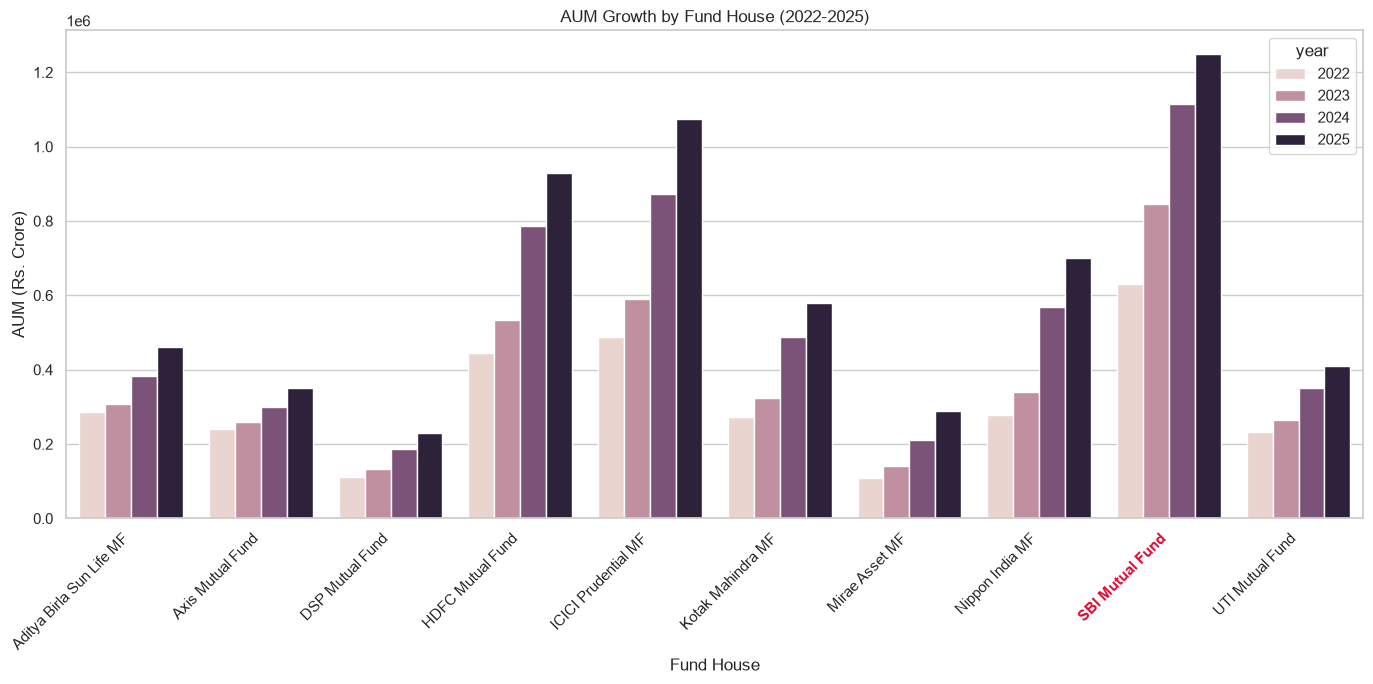

Saved 02_aum_growth_by_fund_house.png


In [3]:
aum_by_fund_house["year"] = aum_by_fund_house["date"].dt.year

yearly_aum = (
    aum_by_fund_house[aum_by_fund_house["year"].between(2022, 2025)]
    .sort_values("date")
    .groupby(["year", "fund_house"], as_index=False)
    .last()[["year", "fund_house", "aum_crore"]]
)

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=yearly_aum, x="fund_house", y="aum_crore", hue="year")
for label in ax.get_xticklabels():
    if "SBI" in label.get_text():
        label.set_color("crimson")
        label.set_fontweight("bold")
plt.xticks(rotation=45, ha="right")
plt.title("AUM Growth by Fund House (2022-2025)")
plt.ylabel("AUM (Rs. Crore)")
plt.xlabel("Fund House")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/02_aum_growth_by_fund_house.png", dpi=150)
plt.show()
print("Saved 02_aum_growth_by_fund_house.png")


## Task 3 — SIP Inflow Time-Series (Jan 2022 – Dec 2025)

Monthly SIP inflow trend with the all-time high annotated.

In [4]:
monthly_sip_inflows["month_parsed"] = pd.to_datetime(monthly_sip_inflows["month"], errors="coerce")
monthly_sip_inflows = monthly_sip_inflows.sort_values("month_parsed")

fig3 = px.line(
    monthly_sip_inflows, x="month_parsed", y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)", markers=True
)

peak_row = monthly_sip_inflows.loc[monthly_sip_inflows["sip_inflow_crore"].idxmax()]
fig3.add_annotation(
    x=peak_row["month_parsed"].strftime("%Y-%m-%d"), y=peak_row["sip_inflow_crore"],
    text=f"All-time high: Rs. {peak_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True, arrowhead=2, yshift=15
)
fig3.update_layout(height=600, xaxis_title="Month", yaxis_title="SIP Inflow (Rs. Crore)")
fig3.show()
fig3.write_image(f"{CHARTS_DIR}/03_sip_inflow_trend.png", width=1400, height=700)
print("Saved 03_sip_inflow_trend.png")
print(f"Peak month: {peak_row['month']}, amount: Rs. {peak_row['sip_inflow_crore']:,.0f} Cr")

Saved 03_sip_inflow_trend.png
Peak month: 2025-12, amount: Rs. 31,002 Cr


## Task 4 — Category Inflow Heatmap

Months on X-axis, fund categories on Y-axis, net inflow as colour intensity.

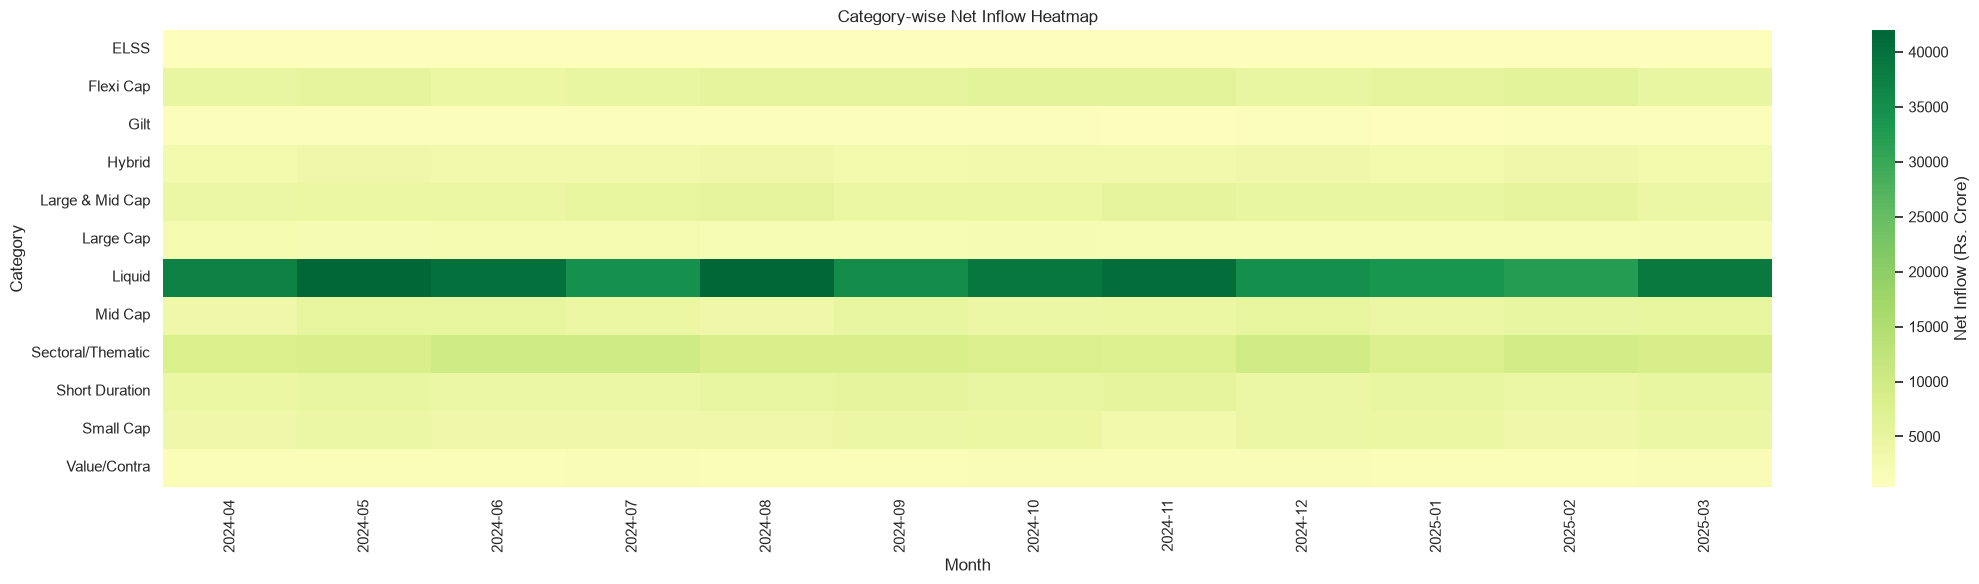

Saved 04_category_inflow_heatmap.png


In [5]:
category_inflows["month_parsed"] = pd.to_datetime(category_inflows["month"], errors="coerce")

pivot_cat = category_inflows.pivot_table(
    index="category", columns="month_parsed", values="net_inflow_crore", aggfunc="sum"
)
pivot_cat = pivot_cat.reindex(sorted(pivot_cat.columns), axis=1)
pivot_cat.columns = [c.strftime("%Y-%m") for c in pivot_cat.columns]

plt.figure(figsize=(22, 6))
sns.heatmap(pivot_cat, cmap="RdYlGn", center=0, cbar_kws={"label": "Net Inflow (Rs. Crore)"})
plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/04_category_inflow_heatmap.png", dpi=150)
plt.show()
print("Saved 04_category_inflow_heatmap.png")


## Task 5 — Investor Demographics

Age group distribution, SIP amount spread by age group, and gender split.

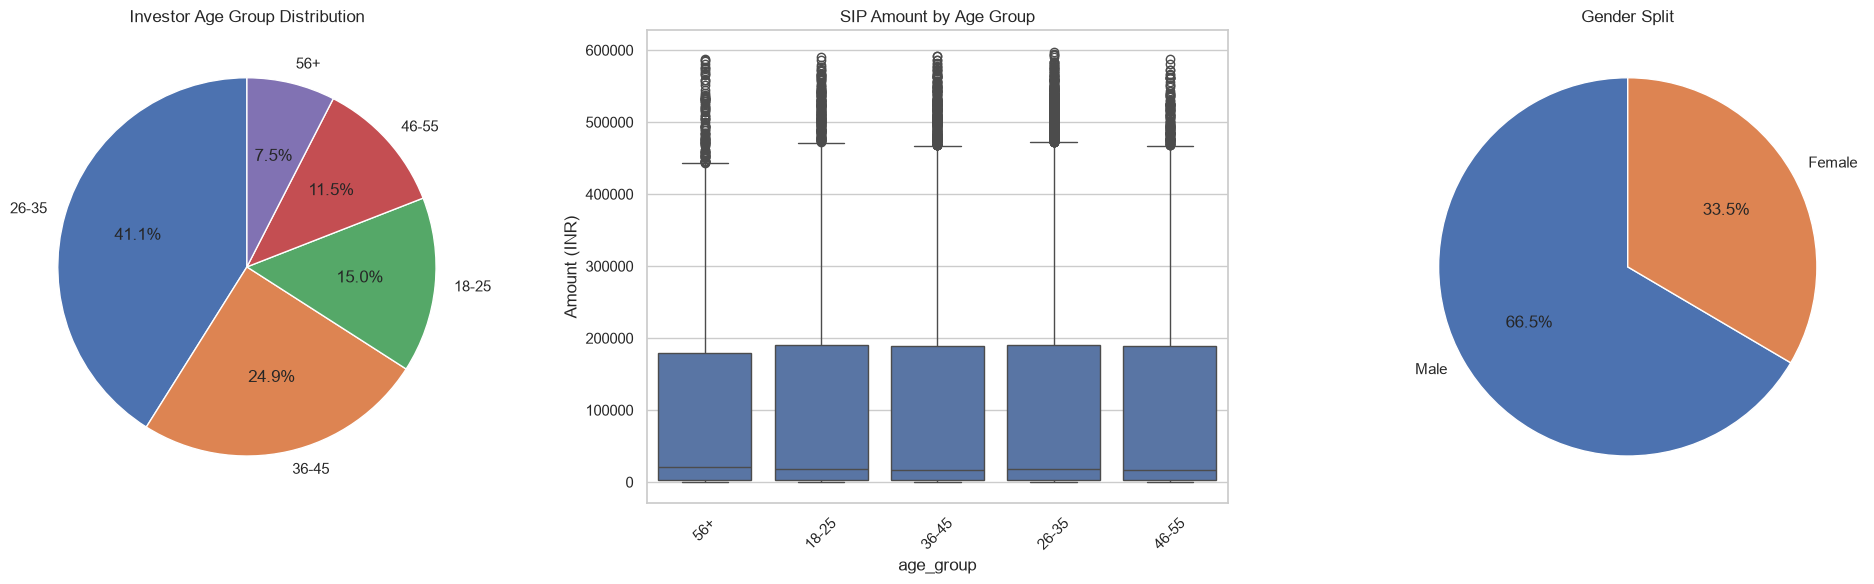

Saved 05_investor_demographics.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

age_counts = investor_transactions["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Investor Age Group Distribution")

sns.boxplot(data=investor_transactions, x="age_group", y="amount_inr", ax=axes[1])
axes[1].set_title("SIP Amount by Age Group")
axes[1].set_ylabel("Amount (INR)")
axes[1].tick_params(axis="x", rotation=45)

gender_counts = investor_transactions["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
axes[2].set_title("Gender Split")

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05_investor_demographics.png", dpi=150)
plt.show()
print("Saved 05_investor_demographics.png")


## Task 6 — Geographic Distribution

SIP amount by state, and T30 vs B30 city tier split.

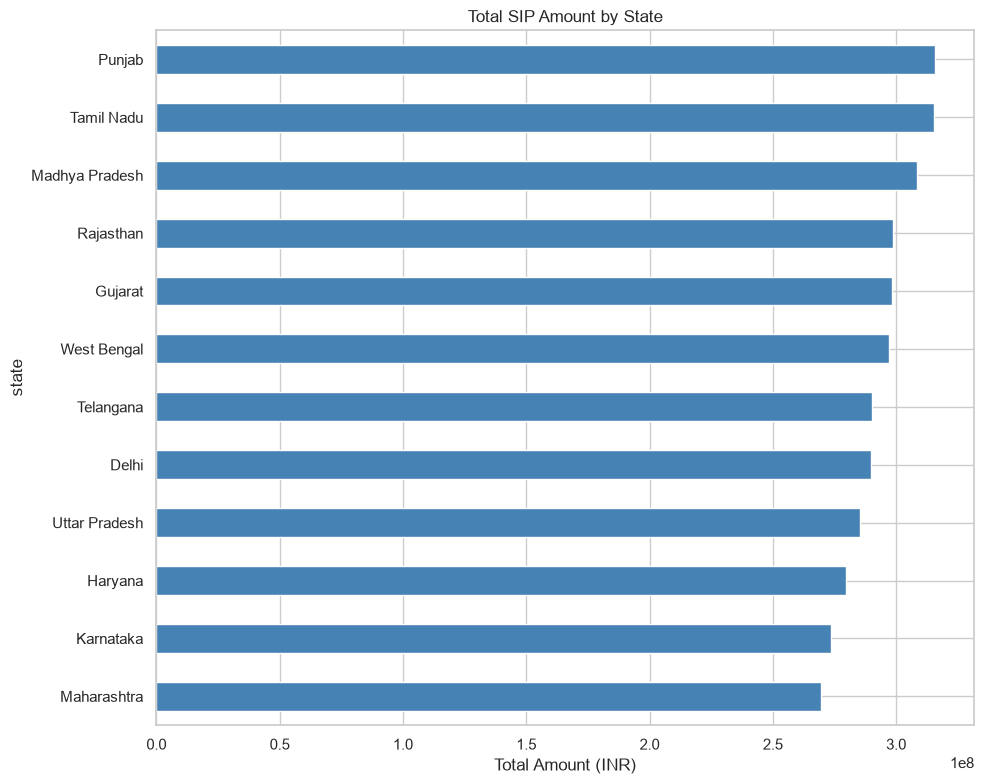

Saved 06a_sip_amount_by_state.png
city_tier unique values found: <StringArray>
['T30', 'B30']
Length: 2, dtype: str


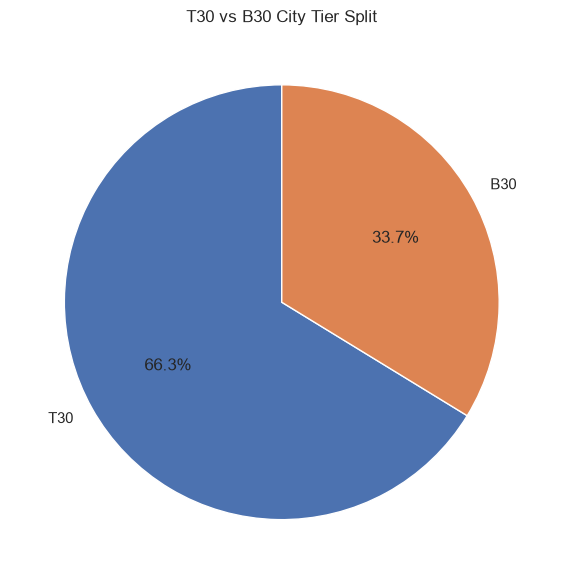

Saved 06b_t30_b30_split.png


In [7]:
state_totals = investor_transactions.groupby("state")["amount_inr"].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
state_totals.plot(kind="barh", color="steelblue")
plt.title("Total SIP Amount by State")
plt.xlabel("Total Amount (INR)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/06a_sip_amount_by_state.png", dpi=150)
plt.show()
print("Saved 06a_sip_amount_by_state.png")

print("city_tier unique values found:", investor_transactions["city_tier"].unique())

tier_counts = investor_transactions["city_tier"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("T30 vs B30 City Tier Split")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/06b_t30_b30_split.png", dpi=150)
plt.show()
print("Saved 06b_t30_b30_split.png")


## Task 7 — Folio Count Growth

Line chart of total folio count from Jan 2022 to Dec 2025, with start/end milestones marked.

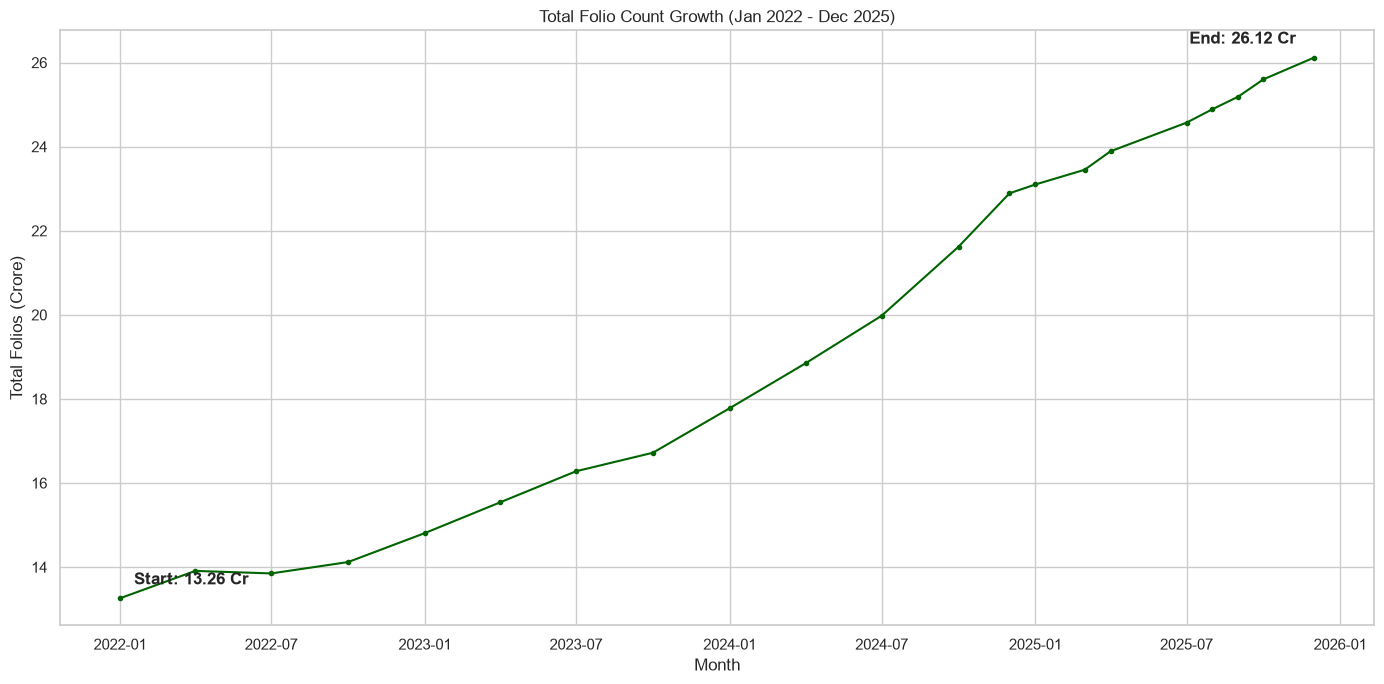

Saved 07_folio_count_growth.png
Growth: 13.26 Cr -> 26.12 Cr


In [8]:
industry_folio_count["month_parsed"] = pd.to_datetime(industry_folio_count["month"], errors="coerce")
industry_folio_count = industry_folio_count.sort_values("month_parsed")

plt.figure(figsize=(14, 7))
plt.plot(industry_folio_count["month_parsed"], industry_folio_count["total_folios_crore"],
          marker="o", markersize=3, color="darkgreen")

start_val = industry_folio_count["total_folios_crore"].iloc[0]
end_val = industry_folio_count["total_folios_crore"].iloc[-1]
start_date = industry_folio_count["month_parsed"].iloc[0]
end_date = industry_folio_count["month_parsed"].iloc[-1]

plt.annotate(f"Start: {start_val:.2f} Cr", xy=(start_date, start_val),
             xytext=(10, 10), textcoords="offset points", fontweight="bold")
plt.annotate(f"End: {end_val:.2f} Cr", xy=(end_date, end_val),
             xytext=(-90, 10), textcoords="offset points", fontweight="bold")

plt.title("Total Folio Count Growth (Jan 2022 - Dec 2025)")
plt.ylabel("Total Folios (Crore)")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/07_folio_count_growth.png", dpi=150)
plt.show()
print("Saved 07_folio_count_growth.png")
print(f"Growth: {start_val:.2f} Cr -> {end_val:.2f} Cr")


## Task 8 — NAV Return Correlation Matrix

Pairwise correlation of daily returns for 10 selected funds.

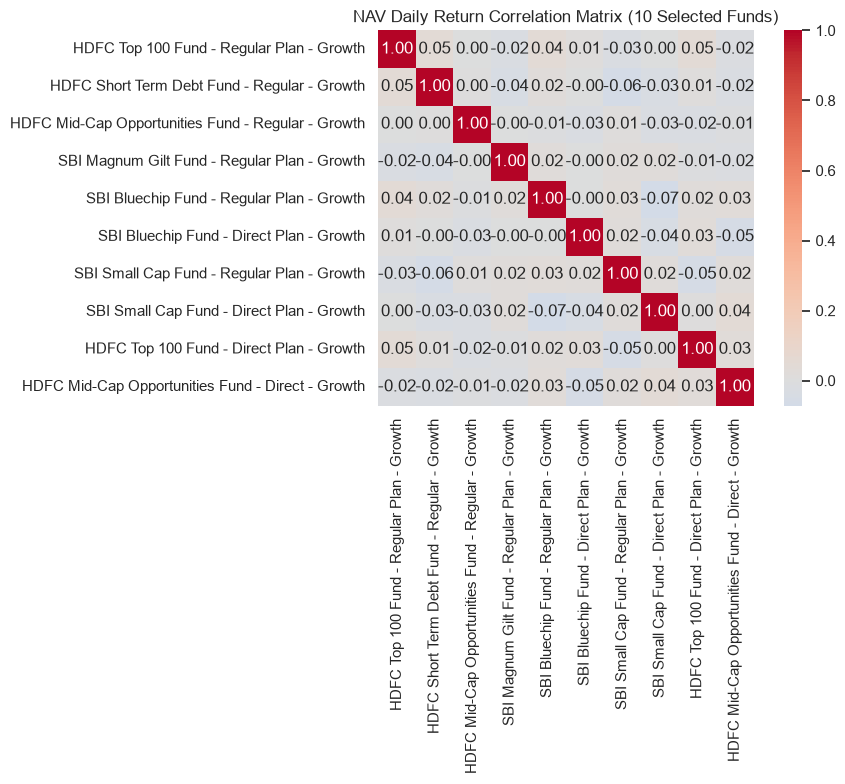

Saved 08_return_correlation_matrix.png


In [9]:
# Selecting the first 10 AMFI codes from fund_master - adjust this list if you want specific named funds instead
selected_codes = fund_master["amfi_code"].unique()[:10]

nav_pivot = nav_history[nav_history["amfi_code"].isin(selected_codes)].pivot(
    index="date", columns="amfi_code", values="nav"
)
returns = nav_pivot.pct_change().dropna()

code_to_name = fund_master.set_index("amfi_code")["scheme_name"].to_dict()
returns.columns = [code_to_name.get(c, c) for c in returns.columns]

corr = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("NAV Daily Return Correlation Matrix (10 Selected Funds)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/08_return_correlation_matrix.png", dpi=150)
plt.show()
print("Saved 08_return_correlation_matrix.png")


## Task 9 — Sector Allocation Donut

Aggregate sector weights from portfolio holdings across all equity funds.

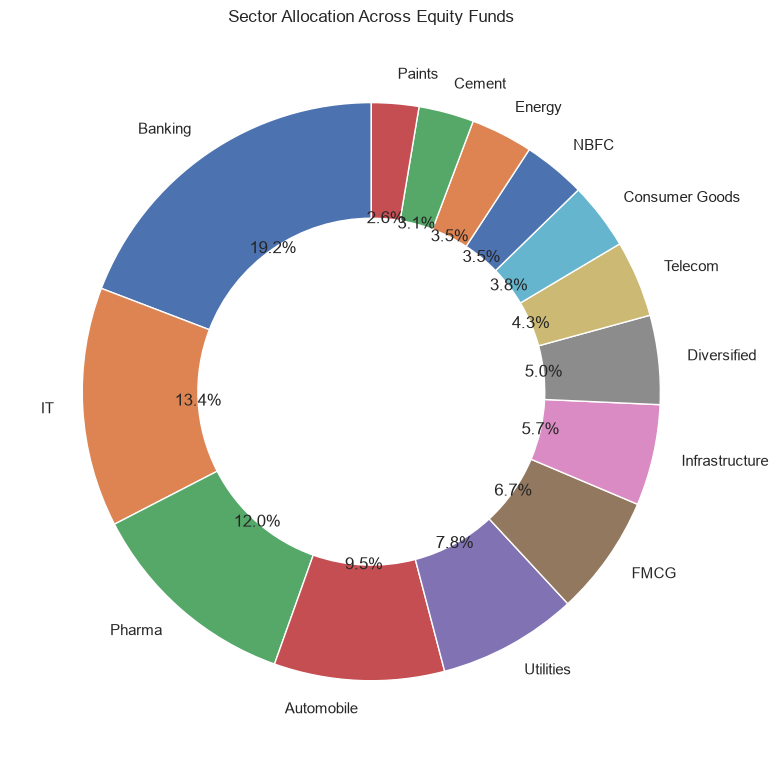

Saved 09_sector_allocation_donut.png


In [10]:
sector_alloc = portfolio_holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(sector_alloc, labels=sector_alloc.index, autopct="%1.1f%%",
        wedgeprops=dict(width=0.4), startangle=90)
plt.title("Sector Allocation Across Equity Funds")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/09_sector_allocation_donut.png", dpi=150)
plt.show()
print("Saved 09_sector_allocation_donut.png")


## Task 10 — Key EDA Findings

1. **NAV Trend (Chart 1):** Most schemes trended steadily upward through the 2023 bull run region, while the standout fund (the green line rising sharply toward ~1200 by 2026) shows a visible dip during the 2024 correction window — dropping from around 850 down to roughly 700 before resuming its climb — whereas the highest-NAV fund (red line, above 3000) continued its steady upward trajectory largely unaffected by the 2024 correction.

2. **AUM Growth (Chart 2):** SBI Mutual Fund shows the steepest growth trajectory of any fund house, more than doubling from ~₹0.63L crore in 2022 to ~₹1.25L crore in 2025, pulling clearly ahead of ICICI Prudential (~₹1.07L crore) and HDFC (~₹0.93L crore) by year-end 2025.

3. **SIP Inflows (Chart 3):** Monthly SIP inflows climbed steadily and almost linearly across the four-year period, roughly tripling from ~₹11,500 crore in January 2022 to an all-time high of ₹31,002 crore in December 2025.

4. **Category Inflows (Chart 4):** Liquid funds dominate net inflows in every single month, consistently the darkest band on the heatmap, while equity categories like Large Cap and Mid Cap stay comparatively flat throughout — showing investor cash remains heavily concentrated in short-term liquid instruments rather than long-term equity exposure.

5. **Age Distribution (Chart 5):** Investors aged 26-35 make up the largest single segment at 41.1%, and together with the 36-45 group (24.9%) account for two-thirds of all investors — though the SIP amount box plot shows median contribution size stays fairly consistent (~₹15,000-20,000) across every age bracket, meaning younger investors are more numerous but not necessarily smaller contributors.

6. **Gender Split (Chart 5):** Male investors account for 66.5% of transactions versus 33.5% for female investors, pointing to a meaningful gender gap in mutual fund participation.

7. **Geographic - State (Chart 6a):** Punjab and Tamil Nadu lead all states in total SIP amount at roughly ₹31.6-31.8 crore each, but the top several states (Punjab, Tamil Nadu, Madhya Pradesh, Rajasthan, Gujarat) sit within a tight ₹27-32 crore band — indicating SIP investment is fairly evenly spread across states rather than dominated by one region.

8. **Geographic - T30/B30 (Chart 6b):** Top-30 cities (T30) account for 66.3% of total SIP amount versus 33.7% from beyond-top-30 cities (B30), showing urban markets still dominate mutual fund penetration despite industry efforts to expand into smaller towns.

9. **Folio Growth (Chart 7):** Total folio count nearly doubled from 13.26 crore in January 2022 to 26.12 crore by December 2025, with growth visibly accelerating from 2024 onward rather than progressing at a steady linear pace.

10. **Return Correlation (Chart 8) / Sector Allocation (Chart 9):** Daily returns across the 10 selected funds show almost no meaningful correlation with each other (values clustering near 0 outside the diagonal), suggesting genuine diversification benefit; separately, sector allocation is heavily concentrated in Banking (19.2%) and IT (13.4%), which together account for nearly a third of all equity holdings across the portfolio.
